### 一、技术指标和滤波

In [1]:
import pickle

file_path = "D:/Courses/量化交易/QuantTrading-Course/Data/future_data/future_data.pkl"

with open(file_path, "rb") as f:
    data = pickle.load(f)

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['A9999.XDCE', 'AD9999.XSGE', 'AG9999.XSGE', 'AL9999.XSGE', 'AO9999.XSGE', 'AP9999.XZCE', 'AU9999.XSGE', 'B9999.XDCE', 'BB9999.XDCE', 'BC9999.XINE', 'BR9999.XSGE', 'BU9999.XSGE', 'BZ9999.XDCE', 'C9999.XDCE', 'CF9999.XZCE', 'CJ9999.XZCE', 'CS9999.XDCE', 'CU9999.XSGE', 'CY9999.XZCE', 'EB9999.XDCE', 'EC9999.XINE', 'EG9999.XDCE', 'FB9999.XDCE', 'FG9999.XZCE', 'FU9999.XSGE', 'HC9999.XSGE', 'I9999.XDCE', 'IC9999.CCFX', 'IF9999.CCFX', 'IH9999.CCFX', 'IM9999.CCFX', 'J9999.XDCE', 'JD9999.XDCE', 'JM9999.XDCE', 'JR9999.XZCE', 'L9999.XDCE', 'LC9999.GFEX', 'LG9999.XDCE', 'LH9999.XDCE', 'LR9999.XZCE', 'LU9999.XINE', 'M9999.XDCE', 'MA9999.XZCE', 'NI9999.XSGE', 'NR9999.XINE', 'OI9999.XZCE', 'OP9999.XSGE', 'P9999.XDCE', 'PB9999.XSGE', 'PD9999.GFEX', 'PF9999.XZCE', 'PG9999.XDCE', 'PK9999.XZCE', 'PL9999.XZCE', 'PM9999.XZCE', 'PP9999.XDCE', 'PR9999.XZCE', 'PS9999.GFEX', 'PT9999.GFEX', 'PX9999.XZCE', 'RB9999.XSGE', 'RI9999.XZCE', 'RM9999.XZCE', 'RR9999.XDCE', 'RS9999.XZCE', 'RU9999

In [2]:
contracts = list(data.keys())
contract = "IF9999.CCFX"
df = data[contract]

print(contract)
print(type(df))
display(df.head())

IF9999.CCFX
<class 'pandas.DataFrame'>


,open,close,high,low,volume,money
2020-01-02 09:31:00,4131.2,4134.0,4138.4,4131.2,3191.0,3.957013e+09
2020-01-02 09:32:00,4134.0,4136.0,4137.8,4134.0,1110.0,1.377323e+09
2020-01-02 09:33:00,4136.4,4142.8,4143.6,4136.4,955.0,1.186188e+09
2020-01-02 09:34:00,4143.2,4139.8,4145.2,4139.6,1024.0,1.272484e+09
2020-01-02 09:35:00,4140.0,4134.8,4140.0,4134.8,578.0,7.175044e+08


In [3]:
import pandas as pd
df.index = pd.to_datetime(df.index)
df = df.sort_index()

daily = df.resample("1D").agg({
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
    "volume": "sum",
    "money": "sum"
})

daily = daily.dropna()

In [4]:
# 图 3.1：均线
daily["MA20"] = daily["close"].rolling(window=20).mean()
daily["MA60"] = daily["close"].rolling(window=60).mean()

# 图 3.2：布林带
k_boll = 20
m_boll = 2
daily["BOLL_MID"] = daily["close"].rolling(window=k_boll).mean()
daily["BOLL_STD"] = daily["close"].rolling(window=k_boll).std()
daily["BOLL_UPPER"] = daily["BOLL_MID"] + m_boll * daily["BOLL_STD"]
daily["BOLL_LOWER"] = daily["BOLL_MID"] - m_boll * daily["BOLL_STD"]

# 图 3.3：RSI 指标
k_rsi = 14
delta = daily["close"].diff()
up = delta.clip(lower=0)
abs_delta = delta.abs()
daily["RSI"] = up.rolling(window=k_rsi).mean() / abs_delta.rolling(window=k_rsi).mean()

# 图 3.4：KDJ 指标
k_kdj = 9
alpha_kdj = 1 / 3
daily["LOW_K"] = daily["low"].rolling(window=k_kdj).min()
daily["HIGH_K"] = daily["high"].rolling(window=k_kdj).max()
daily["RSV"] = (daily["close"] - daily["LOW_K"]) / (daily["HIGH_K"] - daily["LOW_K"])
daily["K"] = daily["RSV"].ewm(alpha=alpha_kdj, adjust=False).mean()
daily["D"] = daily["K"].ewm(alpha=alpha_kdj, adjust=False).mean()
daily["J"] = 3 * daily["K"] - 2 * daily["D"]
daily["K"] = daily["K"].clip(0, 1)

# 图 3.7：HP 滤波
from statsmodels.tsa.filters.hp_filter import hpfilter
daily["HP_100_cycle"], daily["HP_100"] = hpfilter(daily["close"], lamb=100)
daily["HP_10000_cycle"], daily["HP_10000"] = hpfilter(daily["close"], lamb=10000)

# 图 3.8：L1 滤波
import cvxpy as cp
def l1_filter(x, lamb):
    n = len(x)
    y = cp.Variable(n)
    objective = cp.Minimize(
        cp.sum_squares(y - x) + lamb * cp.norm1(y[1:] - y[:-1])
    )
    problem = cp.Problem(objective)
    problem.solve()
    return y.value
x = daily["close"].values
daily["L1_10"] = l1_filter(x, lamb=10)
daily["L1_100"] = l1_filter(x, lamb=100)

# 图 3.9：Fourier 滤波
import numpy as np
def fourier_filter(x, k):
    x = np.asarray(x)
    fft_x = np.fft.fft(x)
    fft_filtered = np.zeros_like(fft_x)
    fft_filtered[:k] = fft_x[:k]
    fft_filtered[-k:] = fft_x[-k:]
    filtered_x = np.fft.ifft(fft_filtered).real
    return filtered_x
x = daily["close"].values
daily["Fourier_10"] = fourier_filter(x, k=10)
daily["Fourier_20"] = fourier_filter(x, k=20)

# Kalman 滤波
def kalman_filter(y, u=1, v=3, x0=None, p0=1):
    y = np.asarray(y)
    n = len(y)
    x_hat = np.zeros(n)
    p = np.zeros(n)
    if x0 is None:
        x_hat[0] = y[0]
    else:
        x_hat[0] = x0
    p[0] = p0
    for i in range(1, n):
        x_prior = x_hat[i - 1]
        q = p[i - 1] + u ** 2
        lam = v ** 2 / (q + v ** 2)
        x_hat[i] = lam * x_prior + (1 - lam) * y[i]
        p[i] = q * v ** 2 / (q + v ** 2)
    return x_hat
x = daily["close"].values
daily["Kalman_u1_v3"] = kalman_filter(x, u=1, v=3)
daily["Kalman_u1_v10"] = kalman_filter(x, u=1, v=10)

In [5]:
daily_full = daily.copy()
daily = daily.loc["2025-01-01":].copy()

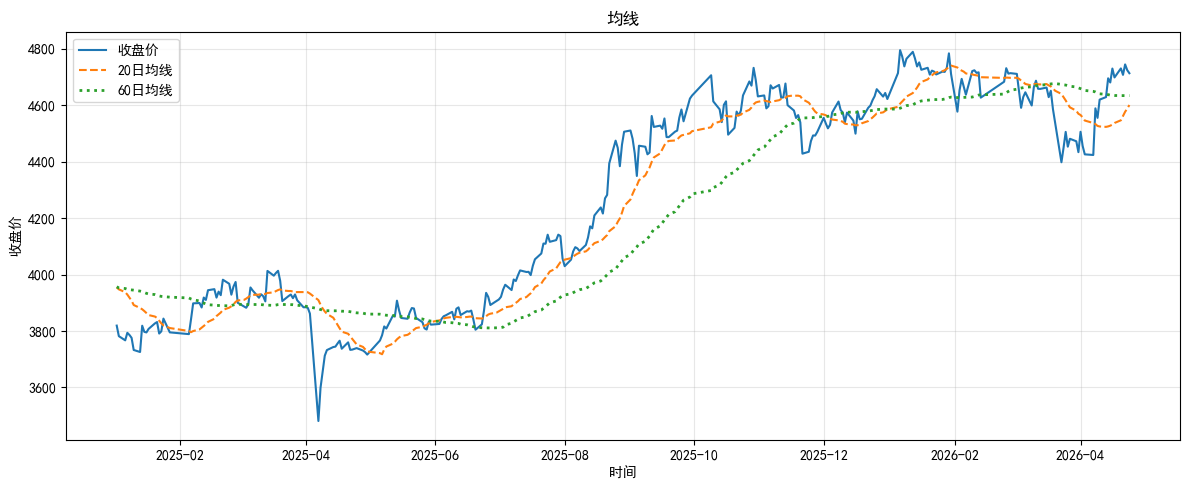

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12, 5))

plt.plot(daily.index, daily["close"], label="收盘价", linewidth=1.5)
plt.plot(daily.index, daily["MA20"], label="20日均线", linestyle="--", linewidth=1.5)
plt.plot(daily.index, daily["MA60"], label="60日均线", linestyle=":", linewidth=2)

plt.xlabel("时间")
plt.ylabel("收盘价")
plt.title("均线")
plt.legend(loc="upper left")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

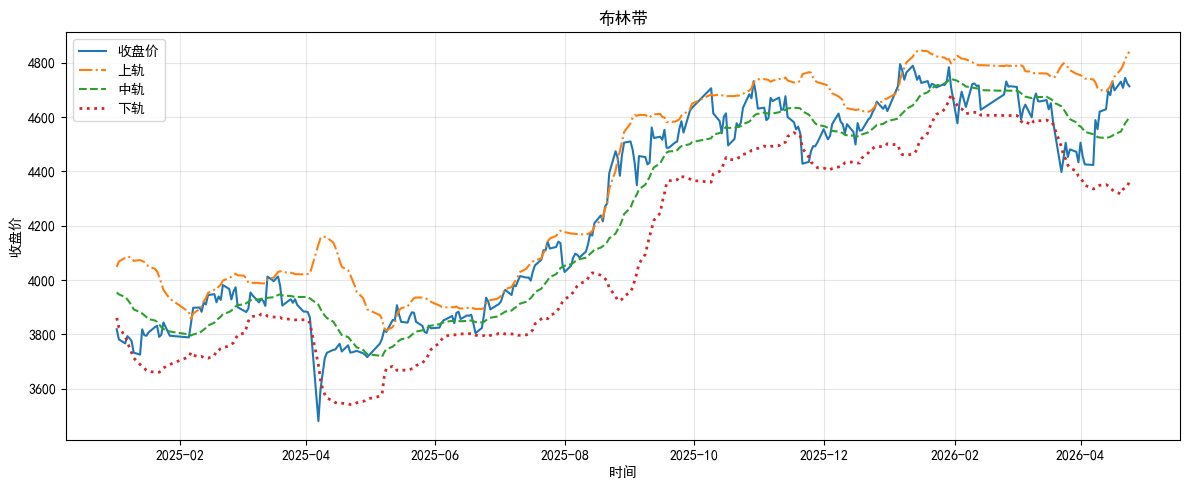

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(daily.index, daily["close"], label="收盘价", linewidth=1.5)
plt.plot(daily.index, daily["BOLL_UPPER"], label="上轨", linestyle="-.", linewidth=1.5)
plt.plot(daily.index, daily["BOLL_MID"], label="中轨", linestyle="--", linewidth=1.5)
plt.plot(daily.index, daily["BOLL_LOWER"], label="下轨", linestyle=":", linewidth=2)

plt.xlabel("时间")
plt.ylabel("收盘价")
plt.title("布林带")
plt.legend(loc="upper left")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

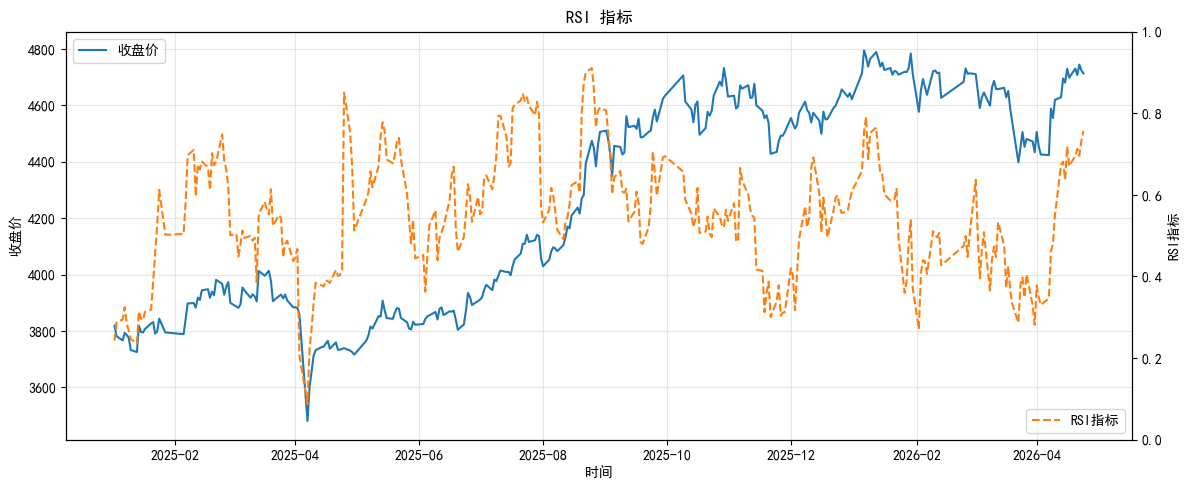

In [8]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    daily.index,
    daily["close"],
    label="收盘价",
    linewidth=1.5,
    color="C0"
)

ax1.set_xlabel("时间")
ax1.set_ylabel("收盘价")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    daily.index,
    daily["RSI"],
    label="RSI指标",
    linestyle="--",
    linewidth=1.5,
    color="C1"
)

ax2.set_ylabel("RSI指标")
ax2.set_ylim(0, 1)
ax2.legend(loc="lower right")

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.title("RSI 指标")
plt.tight_layout()
plt.show()

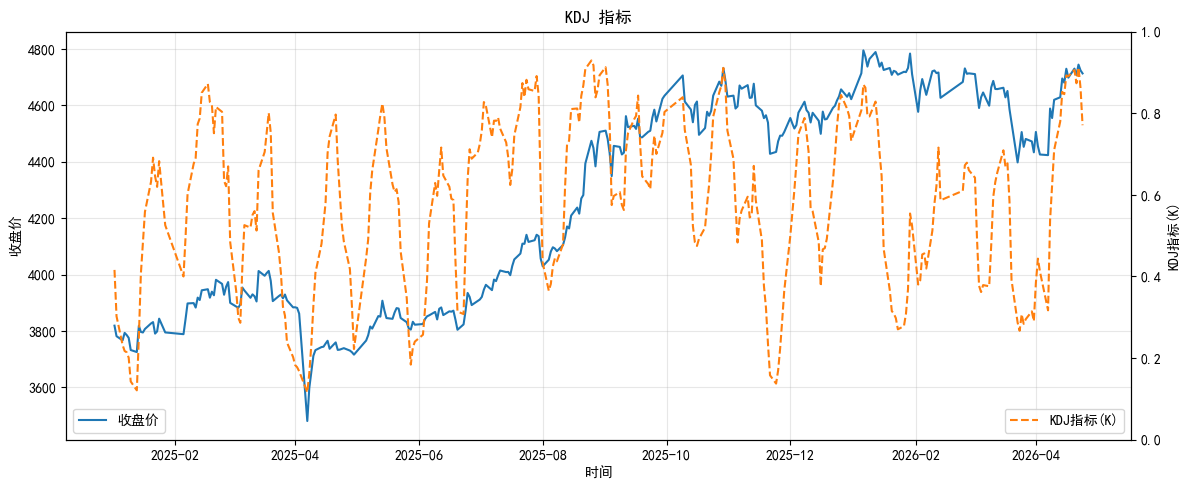

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    daily.index,
    daily["close"],
    label="收盘价",
    linewidth=1.5,
    color="C0"
)

ax1.set_xlabel("时间")
ax1.set_ylabel("收盘价")
ax1.legend(loc="lower left")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    daily.index,
    daily["K"],
    label="KDJ指标(K)",
    linestyle="--",
    linewidth=1.5,
    color="C1"
)

ax2.set_ylabel("KDJ指标(K)")
ax2.set_ylim(0, 1)
ax2.legend(loc="lower right")

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.title("KDJ 指标")
plt.tight_layout()
plt.show()

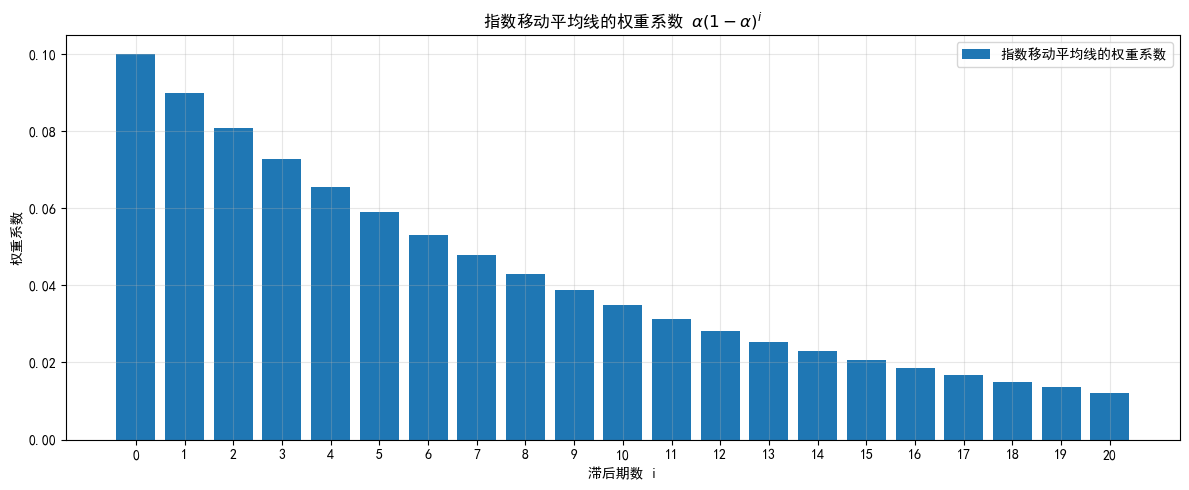

In [10]:
alpha = 0.1

i = np.arange(0, 21)
weights = alpha * (1 - alpha) ** i

plt.figure(figsize=(12, 5))

plt.bar(
    i,
    weights,
    label="指数移动平均线的权重系数"
)

plt.xlabel("滞后期数 i")
plt.ylabel("权重系数")
plt.title(r"指数移动平均线的权重系数 $\alpha(1-\alpha)^i$")
plt.legend(loc="upper right")

plt.xticks(i)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

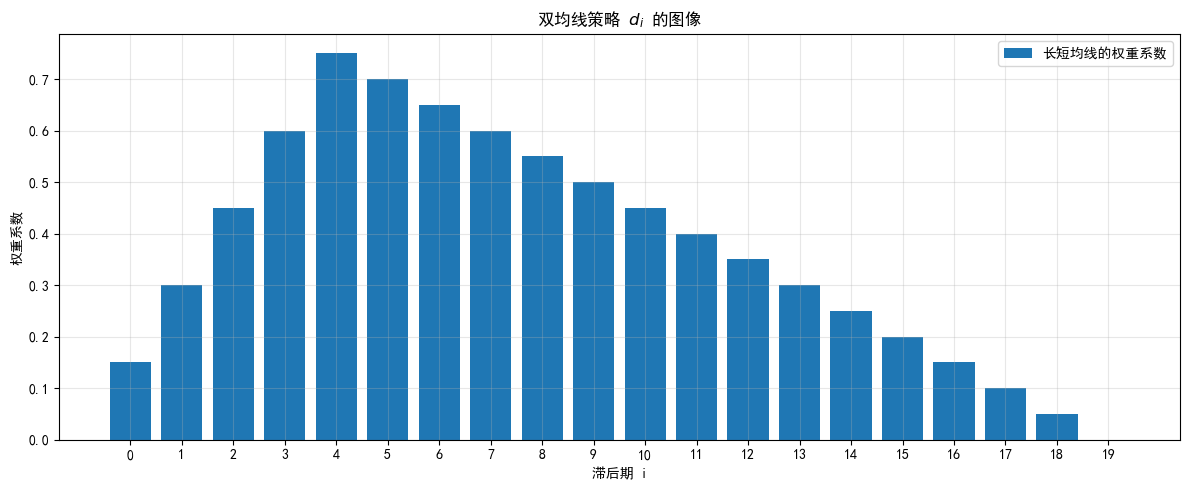

In [11]:
short_window = 5
long_window = 20

a = np.zeros(long_window)
b = np.zeros(long_window)

a[:long_window] = 1 / long_window
b[:short_window] = 1 / short_window

c = b - a
d = np.cumsum(c)

i = np.arange(long_window)

plt.figure(figsize=(12, 5))

plt.bar(
    i,
    d,
    label="长短均线的权重系数"
)

plt.xlabel("滞后期 i")
plt.ylabel("权重系数")
plt.title(r"双均线策略 $d_i$ 的图像")
plt.legend(loc="upper right")

plt.xticks(i)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

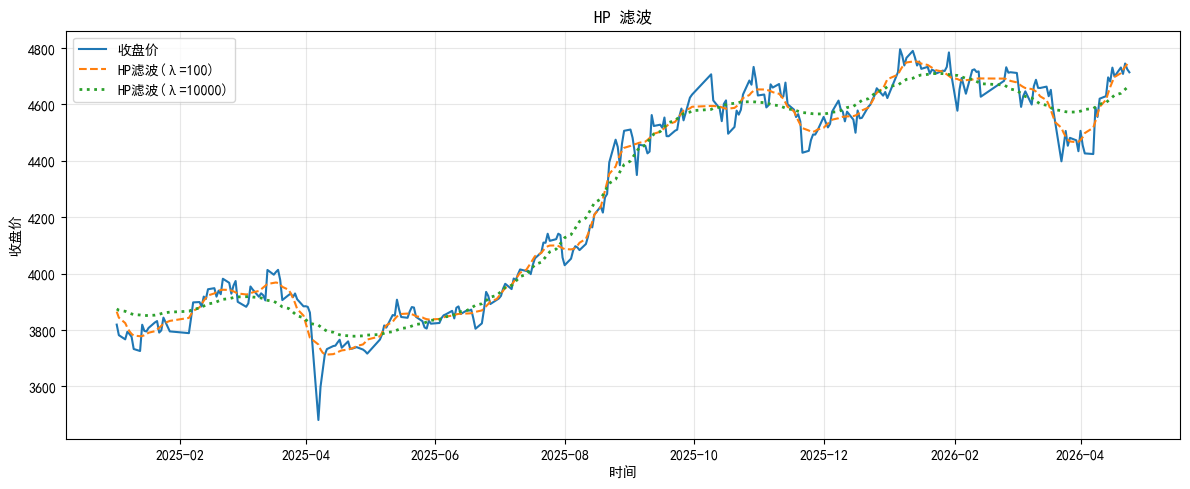

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(daily.index, daily["close"], label="收盘价", linewidth=1.5)
plt.plot(daily.index, daily["HP_100"], label="HP滤波(λ=100)", linestyle="--", linewidth=1.5)
plt.plot(daily.index, daily["HP_10000"], label="HP滤波(λ=10000)", linestyle=":", linewidth=2)

plt.xlabel("时间")
plt.ylabel("收盘价")
plt.title("HP 滤波")
plt.legend(loc="upper left")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

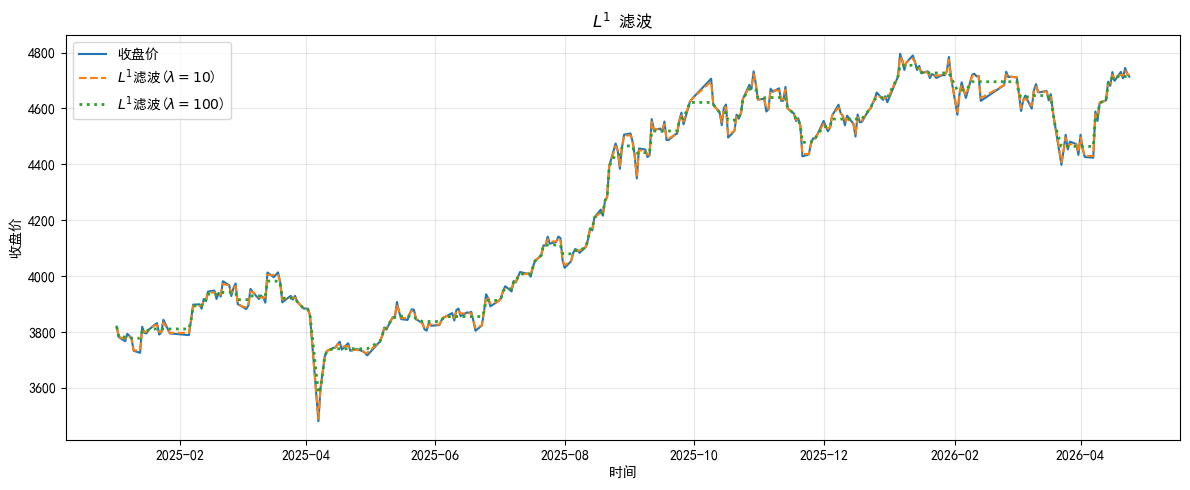

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(daily.index, daily["close"], label="收盘价", linewidth=1.5)
plt.plot(daily.index, daily["L1_10"], label=r"$L^1$滤波($\lambda=10$)", linestyle="--", linewidth=1.5)
plt.plot(daily.index, daily["L1_100"], label=r"$L^1$滤波($\lambda=100$)", linestyle=":", linewidth=2)

plt.xlabel("时间")
plt.ylabel("收盘价")
plt.title(r"$L^1$ 滤波")
plt.legend(loc="upper left")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

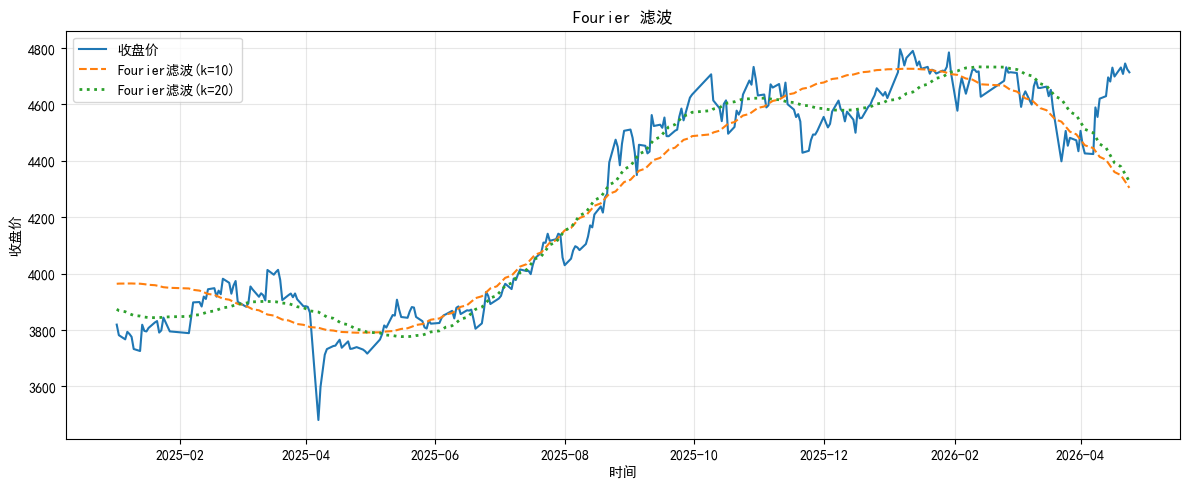

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(daily.index, daily["close"], label="收盘价", linewidth=1.5)
plt.plot(daily.index, daily["Fourier_10"], label="Fourier滤波(k=10)", linestyle="--", linewidth=1.5)
plt.plot(daily.index, daily["Fourier_20"], label="Fourier滤波(k=20)", linestyle=":", linewidth=2)

plt.xlabel("时间")
plt.ylabel("收盘价")
plt.title("Fourier 滤波")
plt.legend(loc="upper left")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 二、改进

In [15]:
# 滚动滤波特征
import numpy as np
import pandas as pd
from statsmodels.tsa.filters.hp_filter import hpfilter
import cvxpy as cp

# 滚动 HP 滤波
def rolling_hp_filter(series, lamb=100, window=180, min_periods=60):
    result = pd.Series(index=series.index, dtype=float)
    for i in range(len(series)):
        if i + 1 < min_periods:
            continue
        start = max(0, i + 1 - window)
        x = series.iloc[start:i+1].dropna()
        if len(x) < min_periods:
            continue
        cycle, trend = hpfilter(x, lamb=lamb)
        result.iloc[i] = trend.iloc[-1]

    return result


# 滚动 Fourier 滤波
def fourier_filter_window(x, k=10):
    x = np.asarray(x, dtype=float)
    mean_x = np.mean(x)
    x_centered = x - mean_x
    fft_values = np.fft.fft(x_centered)
    fft_filtered = np.zeros_like(fft_values)
    fft_filtered[:k] = fft_values[:k]
    fft_filtered[-k+1:] = fft_values[-k+1:]
    filtered = np.fft.ifft(fft_filtered).real + mean_x
    return filtered

def rolling_fourier_filter(series, k=10, window=180, min_periods=60):
    result = pd.Series(index=series.index, dtype=float)
    for i in range(len(series)):
        if i + 1 < min_periods:
            continue
        start = max(0, i + 1 - window)
        x = series.iloc[start:i+1].dropna()
        if len(x) < min_periods:
            continue
        filtered = fourier_filter_window(x.values, k=k)
        result.iloc[i] = filtered[-1]
    return result

# 滚动 L1 滤波
def l1_filter_window(y, lamb=10):
    y = np.asarray(y, dtype=float)
    n = len(y)
    x = cp.Variable(n)
    objective = cp.Minimize(
        0.5 * cp.sum_squares(y - x) + lamb * cp.norm1(cp.diff(x, k=2))
    )
    problem = cp.Problem(objective)
    try:
        problem.solve(solver=cp.CLARABEL, verbose=False)
    except:
        problem.solve(solver=cp.SCS, verbose=False)
    return np.asarray(x.value).flatten()

def rolling_l1_filter(series, lamb=10, window=120, min_periods=60):
    result = pd.Series(index=series.index, dtype=float)
    for i in range(len(series)):
        if i + 1 < min_periods:
            continue
        start = max(0, i + 1 - window)
        x = series.iloc[start:i+1].dropna()
        if len(x) < min_periods:
            continue
        trend = l1_filter_window(x.values, lamb=lamb)
        result.iloc[i] = trend[-1]
    return result

In [16]:
# 无未来信息的滚动滤波特征
model_daily = daily_full.copy()
close_series = model_daily["close"]

# HP 滤波
model_daily["HP_100_roll"] = rolling_hp_filter(
    close_series,
    lamb=100,
    window=180,
    min_periods=60
)
model_daily["HP_10000_roll"] = rolling_hp_filter(
    close_series,
    lamb=10000,
    window=180,
    min_periods=60
)

# Fourier 滤波
model_daily["Fourier_10_roll"] = rolling_fourier_filter(
    close_series,
    k=10,
    window=180,
    min_periods=60
)
model_daily["Fourier_20_roll"] = rolling_fourier_filter(
    close_series,
    k=20,
    window=180,
    min_periods=60
)

# L1 滤波
model_daily["L1_10_roll"] = rolling_l1_filter(
    close_series,
    lamb=10,
    window=120,
    min_periods=60
)
model_daily["L1_100_roll"] = rolling_l1_filter(
    close_series,
    lamb=100,
    window=120,
    min_periods=60
)

In [17]:
# 阶段1：指标 + 滚动滤波 + 线性回归
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 用 t 日及以前的信息，预测 t+1 日收益率
model_daily["ret"] = model_daily["close"].pct_change()
model_daily["target_ret"] = model_daily["ret"].shift(-1)

# 构造衍生特征
model_daily["ma20_gap"] = model_daily["close"] / model_daily["MA20"] - 1
model_daily["ma60_gap"] = model_daily["close"] / model_daily["MA60"] - 1
model_daily["boll_width"] = (
    model_daily["BOLL_UPPER"] - model_daily["BOLL_LOWER"]
) / model_daily["BOLL_MID"]

model_daily["boll_pos"] = (
    model_daily["close"] - model_daily["BOLL_LOWER"]
) / (
    model_daily["BOLL_UPPER"] - model_daily["BOLL_LOWER"]
)

model_daily["hp100_gap"] = model_daily["close"] / model_daily["HP_100_roll"] - 1
model_daily["hp10000_gap"] = model_daily["close"] / model_daily["HP_10000_roll"] - 1

model_daily["l1_10_gap"] = model_daily["close"] / model_daily["L1_10_roll"] - 1
model_daily["l1_100_gap"] = model_daily["close"] / model_daily["L1_100_roll"] - 1

model_daily["fourier10_gap"] = model_daily["close"] / model_daily["Fourier_10_roll"] - 1
model_daily["fourier20_gap"] = model_daily["close"] / model_daily["Fourier_20_roll"] - 1

model_daily["ma20_ma60_gap"] = model_daily["MA20"] / model_daily["MA60"] - 1
model_daily["kd_gap"] = model_daily["K"] - model_daily["D"]
model_daily["j_k_gap"] = model_daily["J"] - model_daily["K"]


# 特征变量
# 指标 + 滚动滤波 + 衍生特征
feature_cols = [
    # 均线指标
    "MA20", "MA60",
    "ma20_gap", "ma60_gap", "ma20_ma60_gap",

    # 布林带指标
    "BOLL_MID", "BOLL_UPPER", "BOLL_LOWER",
    "boll_width", "boll_pos",

    # RSI 和 KDJ
    "RSI", "K", "D", "J",
    "kd_gap", "j_k_gap",

    # 滚动 HP 滤波
    "HP_100_roll", "HP_10000_roll",
    "hp100_gap", "hp10000_gap",

    # 滚动 L1 滤波
    "L1_10_roll", "L1_100_roll",
    "l1_10_gap", "l1_100_gap",

    # 滚动 Fourier 滤波
    "Fourier_10_roll", "Fourier_20_roll",
    "fourier10_gap", "fourier20_gap",
]
data_model = model_daily.dropna(subset=feature_cols + ["target_ret"]).copy()

train = data_model.loc[data_model.index < "2025-01-01"].copy()
test = data_model.loc[data_model.index >= "2025-01-01"].copy()

X_train = train[feature_cols]
y_train = train["target_ret"]

X_test = test[feature_cols]
y_test = test["target_ret"]

print("训练集样本数：", len(train))
print("测试集样本数：", len(test))

# 线性回归模型
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])

lr_model.fit(X_train, y_train)

test["pred_ret"] = lr_model.predict(X_test)


# 预测效果
rmse = np.sqrt(mean_squared_error(y_test, test["pred_ret"]))
mae = mean_absolute_error(y_test, test["pred_ret"])
r2 = r2_score(y_test, test["pred_ret"])
direction_acc = (np.sign(y_test) == np.sign(test["pred_ret"])).mean()
result_base = pd.DataFrame({
    "模型": ["阶段1：基准模型"],
    "RMSE": [rmse],
    "MAE": [mae],
    "R2": [r2],
    "方向准确率": [direction_acc]
})

result_base

训练集样本数： 1153
测试集样本数： 315


,模型,RMSE,MAE,R2,方向准确率
0,阶段1：基准模型,0.011301,0.007799,-0.054057,0.495238


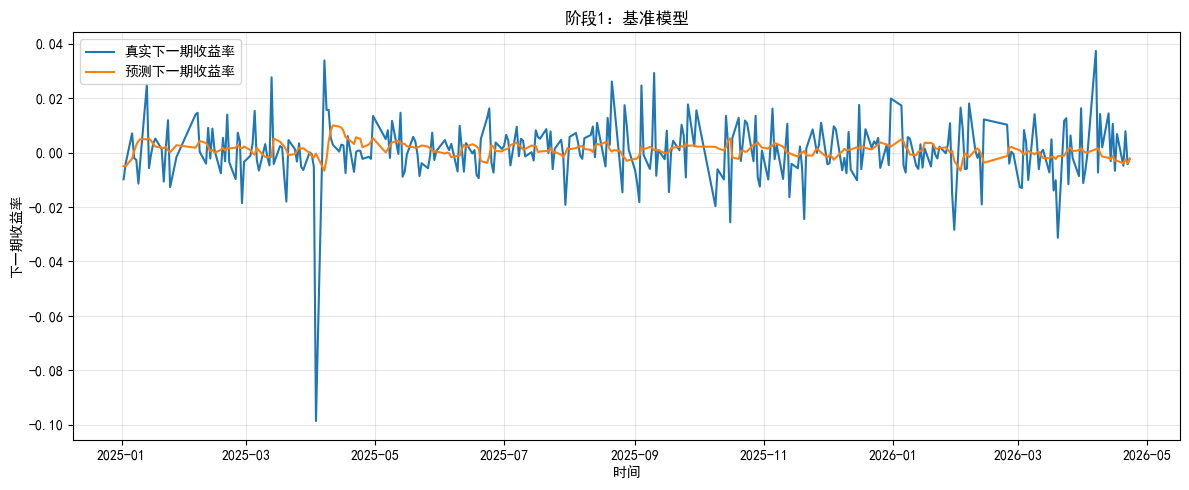

In [18]:
# 阶段1：真实收益率 vs 预测收益率
plt.figure(figsize=(12, 5))
plt.plot(
    test.index,
    y_test,
    label="真实下一期收益率",
    linewidth=1.5
)
plt.plot(
    test.index,
    test["pred_ret"],
    label="预测下一期收益率",
    linewidth=1.5
)

plt.title("阶段1：基准模型")
plt.xlabel("时间")
plt.ylabel("下一期收益率")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# 阶段2：加入 volume、money 和事件变量
model_daily_2 = model_daily.copy()
model_daily_2["ret"] = model_daily_2["close"].pct_change()
model_daily_2["target_ret"] = model_daily_2["ret"].shift(-1)

# 成交量变化率
model_daily_2["volume_chg"] = model_daily_2["volume"].pct_change()

# 成交额变化率
model_daily_2["money_chg"] = model_daily_2["money"].pct_change()

# 成交量的短期均值和长期均值
model_daily_2["volume_ma5"] = model_daily_2["volume"].rolling(5).mean()
model_daily_2["volume_ma20"] = model_daily_2["volume"].rolling(20).mean()

# 成交额的短期均值和长期均值
model_daily_2["money_ma5"] = model_daily_2["money"].rolling(5).mean()
model_daily_2["money_ma20"] = model_daily_2["money"].rolling(20).mean()

# 成交量相对均值的位置
model_daily_2["volume_ratio"] = model_daily_2["volume"] / model_daily_2["volume_ma20"]

# 成交额相对均值的位置
model_daily_2["money_ratio"] = model_daily_2["money"] / model_daily_2["money_ma20"]

# 星期几：0代表周一，4代表周五
model_daily_2["weekday"] = model_daily_2.index.weekday

# 月份效应
model_daily_2["month"] = model_daily_2.index.month

# 是否月初
model_daily_2["is_month_start"] = model_daily_2.index.is_month_start.astype(int)

# 是否月末
model_daily_2["is_month_end"] = model_daily_2.index.is_month_end.astype(int)

# 是否周一
model_daily_2["is_monday"] = (model_daily_2["weekday"] == 0).astype(int)

# 是否周五
model_daily_2["is_friday"] = (model_daily_2["weekday"] == 4).astype(int)

# 是否季度末月份：3、6、9、12月
model_daily_2["is_quarter_end_month"] = model_daily_2["month"].isin([3, 6, 9, 12]).astype(int)


# 特征变量
feature_cols_stage2 = feature_cols + [
    # 交易信息
    "volume", "money",
    "volume_chg", "money_chg",
    "volume_ma5", "volume_ma20",
    "money_ma5", "money_ma20",
    "volume_ratio", "money_ratio",
    # 事件变量
    "weekday", "month",
    "is_month_start", "is_month_end",
    "is_monday", "is_friday",
    "is_quarter_end_month"
]
data_model_2 = model_daily_2.dropna(subset=feature_cols_stage2 + ["target_ret"]).copy()

train_2 = data_model_2.loc[data_model_2.index < "2025-01-01"].copy()
test_2 = data_model_2.loc[data_model_2.index >= "2025-01-01"].copy()

X_train_2 = train_2[feature_cols_stage2]
y_train_2 = train_2["target_ret"]

X_test_2 = test_2[feature_cols_stage2]
y_test_2 = test_2["target_ret"]

print("阶段2训练集样本数：", len(train_2))
print("阶段2测试集样本数：", len(test_2))

# 线性回归模型
lr_model_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])
lr_model_2.fit(X_train_2, y_train_2)
test_2["pred_ret"] = lr_model_2.predict(X_test_2)


# 预测效果
rmse_2 = np.sqrt(mean_squared_error(y_test_2, test_2["pred_ret"]))
mae_2 = mean_absolute_error(y_test_2, test_2["pred_ret"])
r2_2 = r2_score(y_test_2, test_2["pred_ret"])
direction_acc_2 = (np.sign(y_test_2) == np.sign(test_2["pred_ret"])).mean()
result_stage2 = pd.DataFrame({
    "模型": ["阶段2：增加新信息"],
    "RMSE": [rmse_2],
    "MAE": [mae_2],
    "R2": [r2_2],
    "方向准确率": [direction_acc_2]
})

result_stage2

阶段2训练集样本数： 1153
阶段2测试集样本数： 315


,模型,RMSE,MAE,R2,方向准确率
0,阶段2：增加新信息,0.011229,0.008005,-0.04073,0.473016


In [20]:
# 阶段1,2 结果比较
result_compare = pd.concat(
    [result_base, result_stage2],
    ignore_index=True
)

result_compare

,模型,RMSE,MAE,R2,方向准确率
0,阶段1：基准模型,0.011301,0.007799,-0.054057,0.495238
1,阶段2：增加新信息,0.011229,0.008005,-0.040730,0.473016


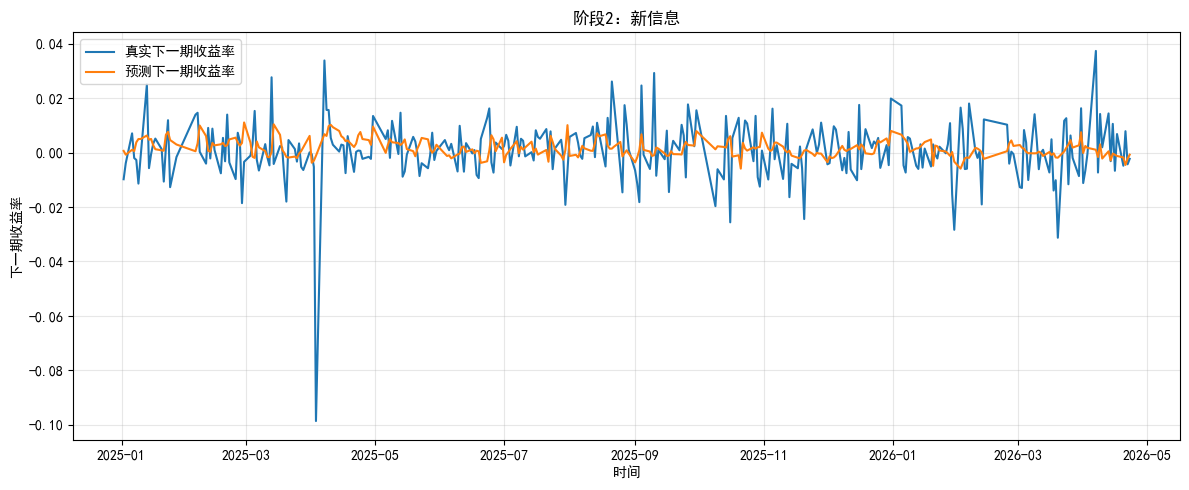

In [22]:
# 阶段2：真实收益率 vs 预测收益率
plt.figure(figsize=(12, 5))
plt.plot(
    test_2.index,
    y_test_2,
    label="真实下一期收益率",
    linewidth=1.5
)
plt.plot(
    test_2.index,
    test_2["pred_ret"],
    label="预测下一期收益率",
    linewidth=1.5
)

plt.title("阶段2：新信息")
plt.xlabel("时间")
plt.ylabel("下一期收益率")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# 阶段3：指标 + 滚动滤波 + 交易信息 + 事件变量 + Ridge岭回归
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_model_3 = model_daily_2.dropna(
    subset=feature_cols_stage2 + ["target_ret"]
).copy()

train_3 = data_model_3.loc[data_model_3.index < "2025-01-01"].copy()
test_3 = data_model_3.loc[data_model_3.index >= "2025-01-01"].copy()

X_train_3 = train_3[feature_cols_stage2]
y_train_3 = train_3["target_ret"]

X_test_3 = test_3[feature_cols_stage2]
y_test_3 = test_3["target_ret"]

print("阶段3训练集样本数：", len(train_3))
print("阶段3测试集样本数：", len(test_3))


# RidgeCV 岭回归
from sklearn.model_selection import TimeSeriesSplit
alphas = np.logspace(-4, 4, 50)
tscv = TimeSeriesSplit(n_splits=5)
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(
        alphas=alphas,
        cv=tscv,
        scoring="neg_mean_squared_error"
    ))
])

ridge_model.fit(X_train_3, y_train_3)
best_alpha = ridge_model.named_steps["ridge"].alpha_
print("Ridge 最优 alpha：", best_alpha)

test_3["pred_ret"] = ridge_model.predict(X_test_3)

rmse_3 = np.sqrt(mean_squared_error(y_test_3, test_3["pred_ret"]))
mae_3 = mean_absolute_error(y_test_3, test_3["pred_ret"])
r2_3 = r2_score(y_test_3, test_3["pred_ret"])
direction_acc_3 = (np.sign(y_test_3) == np.sign(test_3["pred_ret"])).mean()
result_stage3 = pd.DataFrame({
    "模型": [f"阶段3：Ridge岭回归"],
    "RMSE": [rmse_3],
    "MAE": [mae_3],
    "R2": [r2_3],
    "方向准确率": [direction_acc_3]
})

result_stage3

阶段3训练集样本数： 1153
阶段3测试集样本数： 315
Ridge 最优 alpha： 10000.0


,模型,RMSE,MAE,R2,方向准确率
0,阶段3：Ridge岭回归,0.011025,0.007437,-0.003193,0.504762


In [24]:
# 阶段1、阶段2、阶段3 结果比较
result_compare_all = pd.concat(
    [result_base, result_stage2, result_stage3],
    ignore_index=True
)

result_compare_all

,模型,RMSE,MAE,R2,方向准确率
0,阶段1：基准模型,0.011301,0.007799,-0.054057,0.495238
1,阶段2：增加新信息,0.011229,0.008005,-0.040730,0.473016
2,阶段3：Ridge岭回归,0.011025,0.007437,-0.003193,0.504762


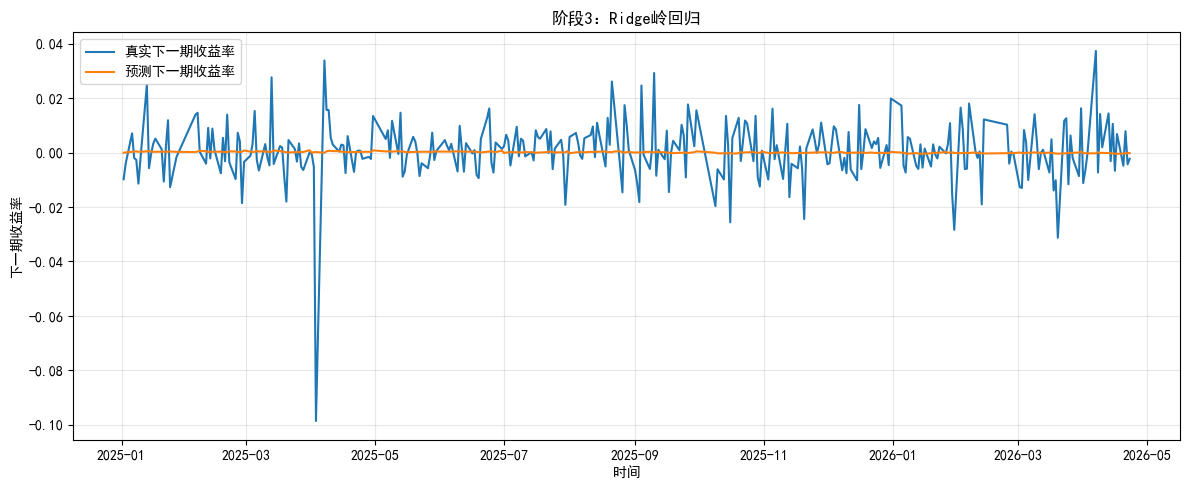

In [25]:
# 阶段3：真实收益率 vs 预测收益率
plt.figure(figsize=(12, 5))
plt.plot(
    test_3.index,
    y_test_3,
    label="真实下一期收益率",
    linewidth=1.5
)
plt.plot(
    test_3.index,
    test_3["pred_ret"],
    label="预测下一期收益率",
    linewidth=1.5
)

plt.title("阶段3：Ridge岭回归")
plt.xlabel("时间")
plt.ylabel("下一期收益率")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# 阶段4：指标 + 滚动滤波 + 交易信息 + 事件变量 + 随机森林
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_model_4 = model_daily_2.dropna(
    subset=feature_cols_stage2 + ["target_ret"]
).copy()

train_4 = data_model_4.loc[data_model_4.index < "2025-01-01"].copy()
test_4 = data_model_4.loc[data_model_4.index >= "2025-01-01"].copy()

X_train_4 = train_4[feature_cols_stage2]
y_train_4 = train_4["target_ret"]

X_test_4 = test_4[feature_cols_stage2]
y_test_4 = test_4["target_ret"]

print("阶段4训练集样本数：", len(train_4))
print("阶段4测试集样本数：", len(test_4))

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [2, 3, 4, 5],
    "min_samples_leaf": [5, 10, 20],
    "max_features": ["sqrt", 0.5, 0.8]
}

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train_4, y_train_4)

print("随机森林最优参数：")
print(grid_search_rf.best_params_)

print("训练集TimeSeriesCV最优MSE：", -grid_search_rf.best_score_)
print("训练集TimeSeriesCV最优RMSE：", np.sqrt(-grid_search_rf.best_score_))

rf_model = grid_search_rf.best_estimator_

test_4["pred_ret"] = rf_model.predict(X_test_4)

rmse_4 = np.sqrt(mean_squared_error(y_test_4, test_4["pred_ret"]))
mae_4 = mean_absolute_error(y_test_4, test_4["pred_ret"])
r2_4 = r2_score(y_test_4, test_4["pred_ret"])
direction_acc_4 = (np.sign(y_test_4) == np.sign(test_4["pred_ret"])).mean()
result_stage4 = pd.DataFrame({
    "模型": ["阶段4：随机森林"],
    "RMSE": [rmse_4],
    "MAE": [mae_4],
    "R2": [r2_4],
    "方向准确率": [direction_acc_4]
})

result_stage4

阶段4训练集样本数： 1153
阶段4测试集样本数： 315
Fitting 5 folds for each of 108 candidates, totalling 540 fits
随机森林最优参数：
{'max_depth': 2, 'max_features': 0.8, 'min_samples_leaf': 5, 'n_estimators': 500}
训练集TimeSeriesCV最优MSE： 0.0001524237684355823
训练集TimeSeriesCV最优RMSE： 0.012346002123585689


,模型,RMSE,MAE,R2,方向准确率
0,阶段4：随机森林,0.011016,0.007452,-0.0015,0.473016


In [27]:
# 阶段1、阶段2、阶段3、阶段4 结果比较
result_compare_all = pd.concat(
    [result_base, result_stage2, result_stage3, result_stage4],
    ignore_index=True
)

result_compare_all

,模型,RMSE,MAE,R2,方向准确率
0,阶段1：基准模型,0.011301,0.007799,-0.054057,0.495238
1,阶段2：增加新信息,0.011229,0.008005,-0.040730,0.473016
2,阶段3：Ridge岭回归,0.011025,0.007437,-0.003193,0.504762
3,阶段4：随机森林,0.011016,0.007452,-0.001500,0.473016


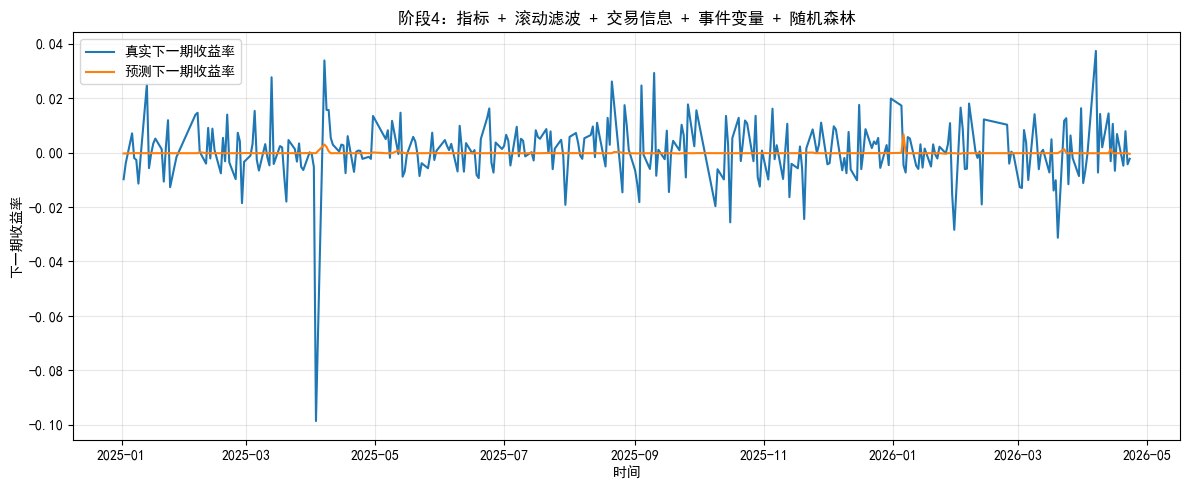

In [28]:
# 阶段4：真实收益率 vs 预测收益率
plt.figure(figsize=(12, 5))
plt.plot(
    test_4.index,
    y_test_4,
    label="真实下一期收益率",
    linewidth=1.5
)
plt.plot(
    test_4.index,
    test_4["pred_ret"],
    label="预测下一期收益率",
    linewidth=1.5
)

plt.title("阶段4：指标 + 滚动滤波 + 交易信息 + 事件变量 + 随机森林")
plt.xlabel("时间")
plt.ylabel("下一期收益率")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

,特征,重要性
9,boll_pos,0.175602
1,MA60,0.169125
19,hp10000_gap,0.115528
3,ma60_gap,0.075428
0,MA20,0.067929
5,BOLL_MID,0.066631
26,fourier10_gap,0.059614
13,J,0.039695
7,BOLL_LOWER,0.030790
18,hp100_gap,0.028592


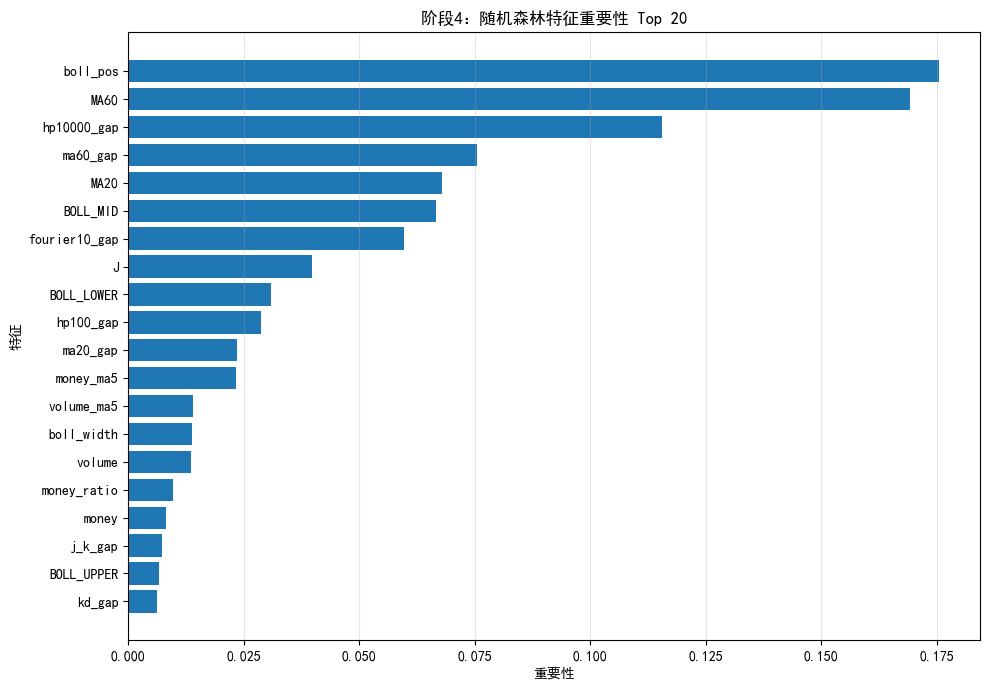

In [ ]:
# 阶段4：随机森林特征重要性
feature_importance = pd.DataFrame({
    "特征": feature_cols_stage2,
    "重要性": rf_model.feature_importances_
}).sort_values("重要性", ascending=False)

display(feature_importance.head(20))

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance.head(20)["特征"][::-1],
    feature_importance.head(20)["重要性"][::-1]
)

plt.title("阶段4：随机森林特征重要性 Top 20")
plt.xlabel("重要性")
plt.ylabel("特征")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()